# Unidad 3 · Programación estocástica de dos etapas: VSS y EVPI

**Planta:** Conservas del Itata S.A.
**Datos:** `DatosClases/3_Planificacion/Planificiacion/` — la misma instancia de los cuadernos 02 a 04, más `itata_escenarios.csv`
**Solver:** Gurobi

---

## Qué se decide aquí

Todos los planes anteriores se construyeron sobre **una** demanda. Esa demanda
es un pronóstico, y un pronóstico no se cumple: la Unidad 2 terminó
entregando, además del valor central, una medida de cuánto puede desviarse.
`itata_escenarios.csv` es esa incertidumbre puesta en la forma que un modelo
de optimización puede leer: ocho trayectorias completas de demanda, cada una
con su probabilidad.

La pregunta no es "cuál escenario va a ocurrir". Es otra, y es la que hace
falta un modelo distinto para responder:

> Hay decisiones que **no se pueden rehacer** cuando llegue la demanda real, y
> decisiones que **sí**. ¿Cómo se eligen las primeras sabiendo que las segundas
> van a poder corregir parte del desajuste?

En Itata el reparto es natural:

| etapa | variables | cuándo se deciden |
|---|---|---|
| **primera** | $y_{it}$ — el patrón de arranques | **ahora**, antes de ver la demanda; es un compromiso de dotación y CIP que se publica en la carta Gantt |
| **segunda** | $x$, $I$, $B$, $o$ — producción, inventario, diferimiento, horas extra | **después**, adaptándose al escenario que ocurra |

## La no anticipatividad, que aquí es implícita

Hay **un solo** juego de variables $y_{it}$, compartido por los ocho
escenarios. Eso no es una comodidad de escritura: es la restricción central
del modelo. Si se escribiera $y_{its}$ sin ligarlas entre escenarios, cada
escenario elegiría su propio patrón de arranques, el óptimo bajaría, y la
solución sería **inimplementable**: exigiría saber en enero qué va a pasar en
marzo. Es el error más caro de esta unidad y no produce ningún mensaje de
error.

## Las cuatro medidas, y el orden que deben respetar

| sigla | qué es |
|---|---|
| **RP** | *recourse problem*: el estocástico, el modelo de arriba |
| **EEV** | costo esperado de **usar** el patrón de arranques del problema con demanda esperada, evaluado en todos los escenarios |
| **WS** | *wait and see*: promedio de resolver cada escenario por separado **sabiendo** cuál ocurrirá |
| **VSS** | $= \text{EEV} - \text{RP}$, valor de la solución estocástica |
| **EVPI** | $= \text{RP} - \text{WS}$, valor de la información perfecta |

Y el orden

$$\text{WS} \;\le\; \text{RP} \;\le\; \text{EEV}$$

**no es un hallazgo empírico: es una desigualdad que debe cumplirse siempre.**
WS relaja la no anticipatividad, así que no puede costar más que RP. EEV fija
la primera etapa a un valor particular —el que salió del problema con demanda
esperada—, así que no puede costar menos que el óptimo sobre todas las
primeras etapas posibles. Si una tabla de resultados no respeta ese orden, no
hay nada que interpretar: hay un error de implementación.

## Advertencia sobre el tamaño del modelo

La licencia gratuita que trae `pip install gurobipy` admite **2 000 variables
y 2 000 restricciones**. El modelo bietapa crece como
$|S| \times |I| \times |T|$, y con los **ocho** escenarios del archivo llega a
**2 184 variables**: no cabe. Este cuaderno trabaja con los **seis escenarios
más probables**, renormalizando sus probabilidades. La sección 5 intenta
construir el de ocho y muestra el error exacto que devuelve la licencia, para
que nadie lo confunda con un problema del modelo. Con licencia académica
—gratuita para estudiantes y docentes— no hay límite y se corre completo.

Reducir escenarios no es solo un truco de licencia: es una técnica estándar
cuando el árbol es grande. Cuánto cambia el óptimo al reducirlo es una
pregunta **empírica**, y está en los ejercicios.

## Cifras de referencia (6 escenarios)

| medida | valor (CLP) | |
|---|---|---|
| WS | 16 388 811 | |
| RP | **17 226 364** | 33 arranques |
| EEV | 17 454 435 | 30 arranques en la solución de demanda esperada |
| **VSS** = EEV − RP | **228 071** | **1,31 %** |
| **EVPI** = RP − WS | **837 553** | **4,86 %** |

In [1]:
import sys
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

dem = pd.read_csv(datos("3_Planificacion", "itata_demanda_plan.csv"))
par = pd.read_csv(datos("3_Planificacion", "itata_parametros_sku.csv"))
cap = pd.read_csv(datos("3_Planificacion", "itata_capacidad.csv"))
tas = pd.read_csv(datos("3_Planificacion", "itata_tasas.csv"))
ini = pd.read_csv(datos("3_Planificacion", "itata_inventario_inicial.csv"))
esc = pd.read_csv(datos("3_Planificacion", "itata_escenarios.csv"))

SKUS = list(par.sku)
T = sorted(dem.t.unique().tolist())
REC = sorted(cap.recurso.unique().tolist())
p = par.set_index("sku")

costo_setup = {i: float(p.loc[i, "costo_setup_clp"]) for i in SKUS}
costo_almacen = {i: float(p.loc[i, "costo_almacen_clp_caja_sem"]) for i in SKUS}
costo_backlog = {i: float(p.loc[i, "costo_backlog_clp_caja_sem"]) for i in SKUS}
inv_final_min = {i: float(p.loc[i, "stock_seguridad_cajas"]) for i in SKUS}

_ini = dict(zip(ini["item"], ini.inventario_inicial.astype(float)))
inv_ini = {i: _ini.get(i, 0.0) for i in SKUS}

linea = dict(zip(tas.sku, tas.linea))
consumo = {}
for _, r in tas.iterrows():
    consumo[(r.sku, "PREP")] = float(r.h_por_caja_PREP)
    consumo[(r.sku, "AUT")] = float(r.h_por_caja_AUT)
    consumo[(r.sku, r.linea)] = float(r.h_por_caja_linea)
tiempo_setup = {(r.sku, linea[r.sku]): float(r.tiempo_setup_h) for _, r in par.iterrows()}

capacidad = {(r.recurso, int(r.t)): float(r.horas_disponibles) for _, r in cap.iterrows()}
extra_max = {(r.recurso, int(r.t)): float(r.horas_extra_max) for _, r in cap.iterrows()}
costo_extra = {(r.recurso, int(r.t)): float(r.costo_hora_extra_clp) for _, r in cap.iterrows()}

ESC = list(dict.fromkeys(esc.escenario))
PROB = {s: float(v) for s, v in esc.groupby("escenario").prob.first().items()}
DEM = {(r.escenario, r.sku, int(r.t)): float(r.demanda_cajas) for _, r in esc.iterrows()}

resumen_esc = pd.DataFrame({
    "prob": pd.Series(PROB),
    "demanda_total": pd.Series({s: sum(DEM[(s, i, t)] for i in SKUS for t in T)
                                for s in ESC})})
resumen_esc["vs_central_%"] = 100 * (resumen_esc.demanda_total
                                     / resumen_esc.loc["s4-central", "demanda_total"] - 1)
print(resumen_esc.to_string(float_format=lambda v: f"{v:,.2f}"))
print(f"\nsuma de probabilidades: {resumen_esc.prob.sum():.3f}")
print(f"demanda esperada      : "
      f"{(resumen_esc.prob * resumen_esc.demanda_total).sum():,.0f} cajas")
print(f"demanda del plan determinístico (cuadernos 02-04): "
      f"{dem.demanda_cajas.sum():,.0f} cajas")

                     prob  demanda_total  vs_central_%
s1-bajo-general      0.10      63,018.00        -17.53
s2-bajo-tom          0.12      66,784.00        -12.60
s3-central-bajo      0.15      72,170.00         -5.56
s4-central           0.22      76,416.00          0.00
s5-central-alto      0.15      81,506.00          6.66
s6-alto-dur          0.11      84,502.00         10.58
s7-alto-general      0.10      91,222.00         19.38
s8-quiebre-contrato  0.05      97,213.00         27.22

suma de probabilidades: 1.000
demanda esperada      : 77,457 cajas
demanda del plan determinístico (cuadernos 02-04): 77,183 cajas


## 1. Reducción a seis escenarios

Se conservan los seis escenarios más probables y se **renormalizan** las
probabilidades para que vuelvan a sumar uno. Renormalizar no es opcional: si
se dejan sumando 0,85, el objetivo esperado queda escalado por 0,85 y todas
las medidas de abajo pierden comparabilidad con cualquier otra corrida.

Los dos que salen son `s7-alto-general` (0,10) y `s8-quiebre-contrato` (0,05),
que es exactamente la clase de escenario que uno preferiría **no** sacar:
el de menor probabilidad es también el de peor consecuencia. Sacarlo baja el
tamaño del modelo y, previsiblemente, baja el VSS, porque el VSS vive de las
colas. Es el precio de la licencia, y hay que decirlo en voz alta en vez de
presentar el resultado de seis escenarios como si fuera el de ocho.

In [2]:
def reducir(k):
    orden = sorted(ESC, key=lambda s: -PROB[s])[:k]
    total = sum(PROB[s] for s in orden)
    return (orden,
            {s: PROB[s] / total for s in orden},
            {kk: v for kk, v in DEM.items() if kk[0] in orden})


S6, P6, D6 = reducir(6)
print("escenarios conservados y probabilidad renormalizada:")
for s in S6:
    print(f"  {s:22s} {PROB[s]:.3f} -> {P6[s]:.4f}")
print(f"  {'suma':22s} {sum(PROB[s] for s in S6):.3f} -> {sum(P6.values()):.4f}")
print("\nfuera:", [s for s in ESC if s not in S6])

escenarios conservados y probabilidad renormalizada:
  s4-central             0.220 -> 0.2588
  s3-central-bajo        0.150 -> 0.1765
  s5-central-alto        0.150 -> 0.1765
  s2-bajo-tom            0.120 -> 0.1412
  s6-alto-dur            0.110 -> 0.1294
  s1-bajo-general        0.100 -> 0.1176
  suma                   0.850 -> 1.0000

fuera: ['s7-alto-general', 's8-quiebre-contrato']


## 2. El modelo

Es el CLSP con backlog y horas extra del cuaderno 03, con una copia de las
variables de segunda etapa por escenario:

$$\min \;\; \underbrace{\sum_{i,t} K_i\, y_{it}}_{\text{primera etapa}}
 \;+\; \sum_s p_s \underbrace{\Big[\sum_{i,t} h_i I_{ist} + b_i B_{ist}
  + \sum_{r,t} c_{rt}\, o_{rst}\Big]}_{\text{recurso del escenario } s}$$

sujeto, **para cada escenario**, al balance de inventario con su propia
demanda, a la capacidad, y al enlace

$$x_{ist} \le M_{it}\, y_{it}$$

donde el subíndice de la derecha es lo único que hay que mirar: $y$ **no**
lleva $s$. Esa ausencia es la no anticipatividad.

**El big-M tiene que ser válido en todos los escenarios.** Con backlog, la
cota "demanda que queda desde $t$" ya no sirve (cuaderno 03), y además hay que
tomar el **peor escenario**: una cota ajustada al escenario central recortaría
soluciones factibles del escenario alto, y —como siempre con un big-M
inválido— el modelo seguiría diciendo `OPTIMAL` y devolvería un costo mayor
que el verdadero óptimo.

La función `construir` sirve para las cuatro medidas: cambia la lista de
escenarios, las probabilidades, la demanda y, opcionalmente, **congela** la
primera etapa en un patrón dado. Esa última opción es la que produce EEV.

In [3]:
def big_M(i, t, S, D):
    """Cota válida con backlog Y bajo todos los escenarios: el peor caso."""
    resto = max(sum(D.get((s, i, u), 0.0) for u in T) for s in S)
    resto = max(0.0, resto - inv_ini[i]) + inv_final_min[i]
    fisico = float("inf")
    for r in REC:
        a = consumo.get((i, r), 0.0)
        if a <= 0:
            continue
        horas = (capacidad.get((r, t), 0.0) + extra_max.get((r, t), 0.0)
                 - tiempo_setup.get((i, r), 0.0))
        fisico = min(fisico, max(0.0, horas) / a)
    return float(min(resto, fisico))


def construir(S, P, D, y_fijo=None, tiempo_limite=300.0, gap=1e-4):
    """Modelo bietapa. y_fijo congela la primera etapa (se usa para EEV)."""
    m = gp.Model("SLS")
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = gap
    m.Params.Seed = 0

    # --- PRIMERA etapa: un solo patrón de arranques para TODOS los escenarios
    y = m.addVars(SKUS, T, vtype=GRB.BINARY, name="y")
    if y_fijo is not None:
        for i in SKUS:
            for t in T:
                y[i, t].LB = y[i, t].UB = float(y_fijo.get((i, t), 0))

    # --- SEGUNDA etapa: una copia por escenario
    x = m.addVars(S, SKUS, T, lb=0.0, name="x")
    I = m.addVars(S, SKUS, T, lb=0.0, name="I")
    B = m.addVars(S, SKUS, T, lb=0.0, name="B")
    o = m.addVars(S, REC, T, lb=0.0, name="o")

    for s in S:
        for i in SKUS:
            for k, t in enumerate(T):
                prev_I = inv_ini[i] if k == 0 else I[s, i, T[k - 1]]
                prev_B = 0.0 if k == 0 else B[s, i, T[k - 1]]
                m.addConstr(prev_I - prev_B + x[s, i, t] - D.get((s, i, t), 0.0)
                            == I[s, i, t] - B[s, i, t], name=f"bal[{s},{i},{t}]")
                m.addConstr(x[s, i, t] <= big_M(i, t, S, D) * y[i, t],
                            name=f"enl[{s},{i},{t}]")
            m.addConstr(B[s, i, T[-1]] == 0.0, name=f"sin_backlog_final[{s},{i}]")
            if inv_final_min[i] > 0:
                m.addConstr(I[s, i, T[-1]] >= inv_final_min[i],
                            name=f"invfinal[{s},{i}]")
        for r in REC:
            for t in T:
                m.addConstr(
                    gp.quicksum(consumo.get((i, r), 0.0) * x[s, i, t]
                                + tiempo_setup.get((i, r), 0.0) * y[i, t]
                                for i in SKUS)
                    <= capacidad[(r, t)] + o[s, r, t], name=f"cap[{s},{r},{t}]")
                m.addConstr(o[s, r, t] <= extra_max[(r, t)], name=f"omax[{s},{r},{t}]")

    primera = gp.quicksum(costo_setup[i] * y[i, t] for i in SKUS for t in T)
    recurso = {s: (gp.quicksum(costo_almacen[i] * I[s, i, t]
                               + costo_backlog[i] * B[s, i, t]
                               for i in SKUS for t in T)
                   + gp.quicksum(costo_extra[(r, t)] * o[s, r, t]
                                 for r in REC for t in T)) for s in S}
    m.setObjective(primera + gp.quicksum(P[s] * recurso[s] for s in S),
                   GRB.MINIMIZE)
    return m, {"y": y, "x": x, "I": I, "B": B, "o": o}, primera, recurso


ESTADO = {GRB.OPTIMAL: "OPTIMAL", GRB.TIME_LIMIT: "TIME_LIMIT",
          GRB.INFEASIBLE: "INFEASIBLE", GRB.INF_OR_UNBD: "INF_OR_UNBD"}


def resolver(etiqueta, S, P, D, y_fijo=None):
    t0 = time.perf_counter()
    m, v, pri, rec = construir(S, P, D, y_fijo=y_fijo)
    m.optimize()
    seg = time.perf_counter() - t0
    print(f"{etiqueta:34s} {ESTADO.get(m.Status, m.Status):9s} "
          f"obj {m.ObjVal:>13,.0f} | gap {100*m.MIPGap:5.2f} % | "
          f"{m.NumVars} var ({m.NumBinVars} bin), {m.NumConstrs} restr "
          f"| {seg:5.1f} s")
    return m, v, pri, rec, seg

## 3. RP: el problema con recurso

Este es el modelo estocástico propiamente tal. Su valor óptimo es **RP**, y su
entregable operativo es la primera etapa: las semanas en que hay que
comprometer un arranque de cada SKU. Todo lo demás —cuánto producir en cada
corrida, cuánto guardar, cuánto diferir— se decidirá cuando llegue la demanda.

In [4]:
m_rp, v_rp, pri_rp, rec_rp, seg_rp = resolver("RP (estocástico, 6 escenarios)",
                                              S6, P6, D6)
RP = m_rp.ObjVal
y_rp = {(i, t): round(v_rp["y"][i, t].X) for i in SKUS for t in T}
setups_rp = int(sum(y_rp.values()))

print(f"\ncosto de primera etapa (arranques) : {pri_rp.getValue():>13,.0f} CLP")
print(f"costo esperado de segunda etapa    : "
      f"{sum(P6[s] * rec_rp[s].getValue() for s in S6):>13,.0f} CLP")
print(f"arranques comprometidos            : {setups_rp:>13d}")

patron = pd.DataFrame([[int(y_rp[(i, t)]) for t in T] for i in SKUS],
                      index=SKUS, columns=T)
patron.columns.name = "semana"
print("\nPrimera etapa: el patrón de arranques que se compromete hoy")
print(patron.to_string())

Restricted license - for non-production use only - expires 2027-11-29


RP (estocástico, 6 escenarios)     OPTIMAL   obj    17,226,364 | gap  0.00 % | 1656 var (72 bin), 1512 restr |  13.4 s

costo de primera etapa (arranques) :    12,780,000 CLP
costo esperado de segunda etapa    :     4,446,364 CLP
arranques comprometidos            :            33

Primera etapa: el patrón de arranques que se compromete hoy
semana    1   2   3   4   5   6   7   8   9   10  11  12
DUR-480    1   1   0   1   0   1   0   1   0   1   1   0
DUR-820    1   0   0   1   0   0   0   0   1   0   0   0
TOM-480    1   1   1   1   1   1   1   1   1   0   1   1
TOM-3000   1   0   1   0   1   0   1   0   0   1   0   0
POR-480    1   0   1   0   1   0   1   0   0   1   0   0
POR-3000   0   1   0   0   0   0   0   1   0   0   0   0


## 4. EEV y WS

### EEV: qué pasa si se planifica con el promedio

Es lo que hace casi todo el mundo: se toma la demanda esperada, se resuelve el
determinístico de siempre, y se ejecuta ese plan. El problema es que el plan
no se ejecuta en un mundo promedio: se ejecuta en un escenario concreto. EEV
mide eso en dos pasos, y el segundo es el que se olvida:

1. resolver el determinístico con $\bar d_{it} = \sum_s p_s\, d_{ist}$ y
   quedarse con su patrón de arranques $\bar y$;
2. **congelar** $\bar y$ y volver a resolver sobre los seis escenarios,
   dejando que la segunda etapa haga lo que pueda.

El costo del paso 1 no es EEV y no es comparable con nada: es el costo de un
mundo que no existe. EEV es el del paso 2.

### WS: el valor de una bola de cristal

Se resuelve cada escenario **por separado**, sabiendo de antemano cuál va a
ocurrir, y se promedia. No es un plan: no hay ningún patrón de arranques que
lo implemente, porque cada escenario elige el suyo. Es una **cota inferior**,
y su distancia a RP es lo que valdría un pronóstico perfecto.

In [5]:
d_esperada = {("EV", i, t): sum(P6[s] * D6.get((s, i, t), 0.0) for s in S6)
              for i in SKUS for t in T}
m_ev, v_ev, pri_ev, _, _ = resolver("determinístico con demanda esperada",
                                    ["EV"], {"EV": 1.0}, d_esperada)
y_ev = {(i, t): round(v_ev["y"][i, t].X) for i in SKUS for t in T}
setups_ev = int(sum(y_ev.values()))
print(f"   (este valor NO es EEV: es el costo de un mundo promedio que no ocurre)")

m_eev, v_eev, _, rec_eev, _ = resolver("EEV (patrón del promedio, evaluado)",
                                       S6, P6, D6, y_fijo=y_ev)
EEV = m_eev.ObjVal

WS, ws_detalle = 0.0, {}
for s in S6:
    d_s = {(s, i, t): D6.get((s, i, t), 0.0) for i in SKUS for t in T}
    m_s, v_s, _, _, _ = resolver(f"WS · {s}", [s], {s: 1.0}, d_s)
    ws_detalle[s] = m_s.ObjVal
    WS += P6[s] * m_s.ObjVal

print(f"\narranques del patrón estocástico (RP)      : {setups_rp}")
print(f"arranques del patrón de demanda esperada   : {setups_ev}")
coinciden = sum(1 for k in y_rp if y_rp[k] == y_ev[k])
print(f"celdas (SKU, semana) en que ambos coinciden: {coinciden} de {len(y_rp)}")
print("\nEl plan estocástico compromete MÁS arranques que el del promedio. No es")
print("un descuido: son arranques que no se justifican contra la demanda media y")
print("sí contra la posibilidad de una demanda alta. Esa diferencia es,")
print("literalmente, lo que el modelo estocástico compra.")

determinístico con demanda esperada OPTIMAL   obj    15,433,306 | gap  0.00 % | 336 var (72 bin), 252 restr |   1.7 s
   (este valor NO es EEV: es el costo de un mundo promedio que no ocurre)
EEV (patrón del promedio, evaluado) OPTIMAL   obj    17,454,435 | gap  0.00 % | 1656 var (72 bin), 1512 restr |   0.0 s


WS · s4-central                    OPTIMAL   obj    15,888,530 | gap  0.00 % | 336 var (72 bin), 252 restr |   2.1 s


WS · s3-central-bajo               OPTIMAL   obj    15,016,227 | gap  0.00 % | 336 var (72 bin), 252 restr |   3.6 s


WS · s5-central-alto               OPTIMAL   obj    18,956,928 | gap  0.00 % | 336 var (72 bin), 252 restr |   4.0 s


WS · s2-bajo-tom                   OPTIMAL   obj    14,232,348 | gap  0.00 % | 336 var (72 bin), 252 restr |   1.8 s


WS · s6-alto-dur                   OPTIMAL   obj    20,582,794 | gap  0.00 % | 336 var (72 bin), 252 restr |   7.7 s


WS · s1-bajo-general               OPTIMAL   obj    13,670,504 | gap  0.00 % | 336 var (72 bin), 252 restr |   1.5 s

arranques del patrón estocástico (RP)      : 33
arranques del patrón de demanda esperada   : 30
celdas (SKU, semana) en que ambos coinciden: 47 de 72

El plan estocástico compromete MÁS arranques que el del promedio. No es
un descuido: son arranques que no se justifican contra la demanda media y
sí contra la posibilidad de una demanda alta. Esa diferencia es,
literalmente, lo que el modelo estocástico compra.


## 5. El límite de la licencia, visto de frente

Antes de mirar las medidas conviene comprobar la afirmación del encabezado, en
vez de creerla. Se intenta construir el modelo con los ocho escenarios y se
atrapa el error. El mensaje de Gurobi es inconfundible y no tiene nada que ver
con el modelo: no dice "infactible", no dice "mal formulado", dice que el
modelo es **demasiado grande para una licencia limitada por tamaño**.

In [6]:
S8, P8, D8 = reducir(8)
n_var_8 = len(SKUS) * len(T) * (1 + 3 * len(S8)) + len(S8) * len(REC) * len(T)
print(f"variables que tendría el modelo de 8 escenarios: {n_var_8:,d}")
print(f"variables del modelo de 6 escenarios           : {m_rp.NumVars:,d}")
print(f"restricciones del modelo de 6 escenarios       : {m_rp.NumConstrs:,d}")
print("límite de la licencia gratuita de pip          : 2,000 / 2,000\n")
try:
    m8, *_ = construir(S8, P8, D8)
    m8.optimize()
    print(f"El modelo de 8 escenarios SÍ cupo: obj {m8.ObjVal:,.0f} CLP")
    print("(licencia académica o sin restricción de tamaño)")
    licencia_limitada = False
except gp.GurobiError as e:
    licencia_limitada = True
    print(f"GurobiError: {e}")
    print("\nEs un límite de la LICENCIA, no del modelo ni del computador. Con")
    print("licencia académica el mismo código corre con los ocho escenarios.")

variables que tendría el modelo de 8 escenarios: 2,184
variables del modelo de 6 escenarios           : 1,656
restricciones del modelo de 6 escenarios       : 1,512
límite de la licencia gratuita de pip          : 2,000 / 2,000

GurobiError: Model too large for size-limited license; visit https://gurobi.com/unrestricted for more information

Es un límite de la LICENCIA, no del modelo ni del computador. Con
licencia académica el mismo código corre con los ocho escenarios.


## 6. Las cuatro medidas

VSS y EVPI son cifras que **se calculan**. Un informe que dice "usamos el
modelo estocástico porque captura mejor la incertidumbre" y no trae el VSS no
ha demostrado nada. Y un VSS de cero es un resultado perfectamente
respetable: significa que en esta instancia el modelo estocástico sobra, y
saberlo ahorra trabajo.

In [7]:
VSS, EVPI = EEV - RP, RP - WS
medidas = pd.DataFrame({
    "valor_CLP": [WS, RP, EEV],
    "qué es": ["información perfecta (cota inferior, no implementable)",
               "estocástico con recurso (el plan que se entrega)",
               "patrón del promedio evaluado en todos los escenarios"]},
    index=["WS", "RP", "EEV"])
print(medidas.to_string(float_format=lambda v: f"{v:,.0f}"))
print()
print(f"  VSS  = EEV - RP = {VSS:>12,.0f} CLP   ({100*VSS/EEV:5.2f} % de EEV)")
print(f"  EVPI = RP  - WS = {EVPI:>12,.0f} CLP   ({100*EVPI/RP:5.2f} % de RP)")

print("\nOrden teórico WS <= RP <= EEV:")
print(f"  WS <= RP : {WS:>12,.0f} <= {RP:>12,.0f}   "
      f"{'OK' if WS <= RP + 1e-6 else 'FALLA'}")
print(f"  RP <= EEV: {RP:>12,.0f} <= {EEV:>12,.0f}   "
      f"{'OK' if RP <= EEV + 1e-6 else 'FALLA'}")

print("\nCosto de cada escenario bajo información perfecta (WS):")
det = pd.DataFrame({"prob": pd.Series(P6), "costo_WS": pd.Series(ws_detalle)})
det["costo_RP_en_el_escenario"] = pd.Series(
    {s: pri_rp.getValue() + rec_rp[s].getValue() for s in S6})
det["costo_EEV_en_el_escenario"] = pd.Series(
    {s: sum(costo_setup[i] * y_ev[(i, t)] for i in SKUS for t in T)
     + rec_eev[s].getValue() for s in S6})
det["sobrecosto_RP_%"] = 100 * (det.costo_RP_en_el_escenario / det.costo_WS - 1)
print(det.to_string(float_format=lambda v: f"{v:,.2f}"))

     valor_CLP                                                  qué es
WS  16,388,811  información perfecta (cota inferior, no implementable)
RP  17,226,364        estocástico con recurso (el plan que se entrega)
EEV 17,454,435    patrón del promedio evaluado en todos los escenarios

  VSS  = EEV - RP =      228,071 CLP   ( 1.31 % de EEV)
  EVPI = RP  - WS =      837,553 CLP   ( 4.86 % de RP)

Orden teórico WS <= RP <= EEV:
  WS <= RP :   16,388,811 <=   17,226,364   OK
  RP <= EEV:   17,226,364 <=   17,454,435   OK

Costo de cada escenario bajo información perfecta (WS):
                 prob      costo_WS  costo_RP_en_el_escenario  costo_EEV_en_el_escenario  sobrecosto_RP_%
s4-central       0.26 15,888,530.19             16,260,614.82              16,013,211.54             2.34
s3-central-bajo  0.18 15,016,227.13             15,617,675.50              15,106,010.28             4.01
s5-central-alto  0.18 18,956,927.68             19,338,263.70              21,070,898.12             2.

### Cómo se lee

**El EVPI es cuatro veces el VSS.** En esta instancia, lo que valdría saber
de antemano la demanda (837 553 CLP) es mucho más que lo que vale modelar la
incertidumbre en vez de usar el promedio (228 071 CLP). Las dos cifras
responden preguntas distintas y compiten por el mismo presupuesto: el VSS dice
cuánto pagar por un mejor **modelo**, el EVPI cuánto pagar por un mejor
**pronóstico**. Aquí la plata está mejor puesta en la Unidad 2 que en la 3, y
ese es un resultado de gestión, no un tecnicismo.

**El VSS es chico, y hay dos razones.** La primera es honesta: Itata tiene
backlog y horas extra, es decir, **segunda etapa flexible**. Cuando el recurso
puede arreglar casi todo, la primera etapa importa poco y el VSS se achica. Un
modelo sin backlog y sin horas extra —donde equivocarse en un arranque
significa no vender— daría un VSS mucho mayor. La segunda razón es el precio
de la licencia: se sacaron los dos escenarios extremos, y el VSS vive
precisamente de las colas.

**La columna `sobrecosto_RP_%` es el argumento comercial.** Muestra cuánto
peor le va al plan estocástico que a un adivino, escenario por escenario. Es
la forma de presentarle el resultado a alguien que no va a leer una tabla de
siglas.

## 7. El gráfico del cuaderno

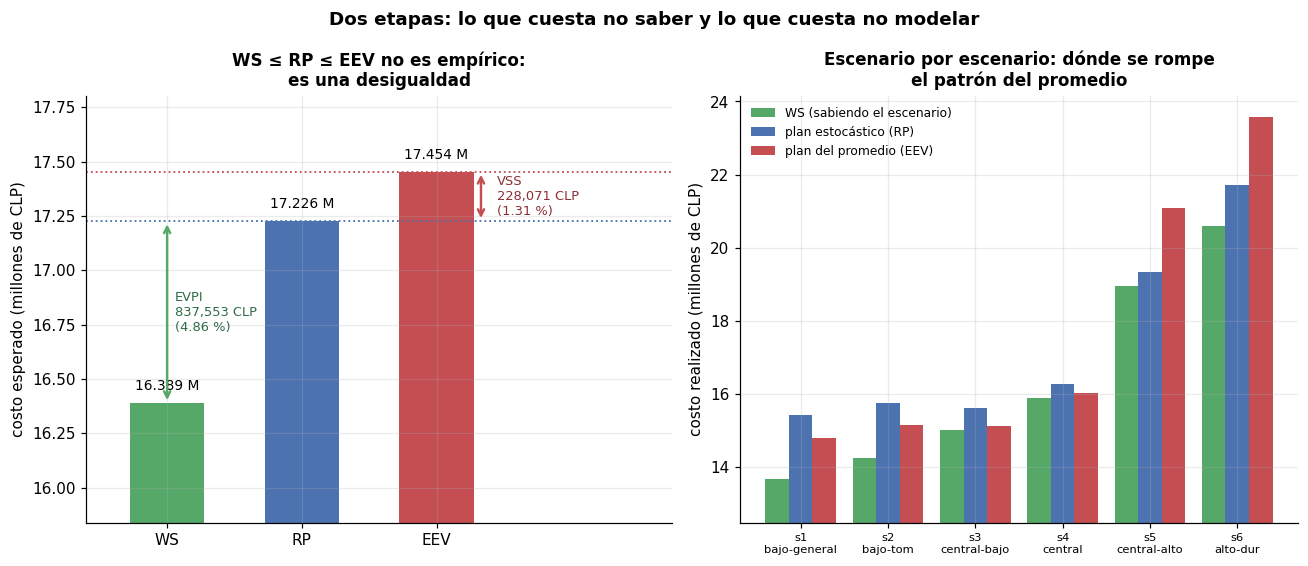

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.0, 5.2),
                               gridspec_kw={"width_ratios": [1.05, 1]})

nombres = ["WS", "RP", "EEV"]
vals = [WS, RP, EEV]
colores = ["#55a868", "#4c72b0", "#c44e52"]
barras = ax1.bar(nombres, [v / 1e6 for v in vals], color=colores, width=0.55)
for b, v in zip(barras, vals):
    ax1.text(b.get_x() + b.get_width() / 2, v / 1e6 + 0.06, f"{v/1e6:,.3f} M",
             ha="center", fontsize=9)
base = WS / 1e6 - 0.55
ax1.set_ylim(base, EEV / 1e6 + 0.35)

ax1.annotate("", xy=(0, RP / 1e6), xytext=(0, WS / 1e6),
             arrowprops=dict(arrowstyle="<->", color="#55a868", lw=1.6))
ax1.text(0.06, (WS + RP) / 2e6, f"EVPI\n{EVPI:,.0f} CLP\n({100*EVPI/RP:.2f} %)",
         fontsize=8.5, color="#2f6b47", va="center")
ax1.annotate("", xy=(2.33, EEV / 1e6), xytext=(2.33, RP / 1e6),
             arrowprops=dict(arrowstyle="<->", color="#c44e52", lw=1.6))
ax1.text(2.45, (RP + EEV) / 2e6, f"VSS\n{VSS:,.0f} CLP\n({100*VSS/EEV:.2f} %)",
         fontsize=8.5, color="#8c2f33", va="center", ha="left")
ax1.axhline(EEV / 1e6, color="#c44e52", ls=":", lw=1.2)
ax1.set_xlim(-0.6, 3.75)
ax1.axhline(RP / 1e6, color="#4c72b0", ls=":", lw=1.2)
ax1.set_ylabel("costo esperado (millones de CLP)")
ax1.set_title("WS ≤ RP ≤ EEV no es empírico:\nes una desigualdad", fontsize=11)

orden = sorted(S6, key=lambda s: det.loc[s, "costo_WS"])
xx = np.arange(len(orden))
ax2.bar(xx - 0.27, [det.loc[s, "costo_WS"] / 1e6 for s in orden], 0.27,
        color="#55a868", label="WS (sabiendo el escenario)")
ax2.bar(xx, [det.loc[s, "costo_RP_en_el_escenario"] / 1e6 for s in orden], 0.27,
        color="#4c72b0", label="plan estocástico (RP)")
ax2.bar(xx + 0.27, [det.loc[s, "costo_EEV_en_el_escenario"] / 1e6 for s in orden],
        0.27, color="#c44e52", label="plan del promedio (EEV)")
ax2.set_xticks(xx)
ax2.set_xticklabels([s.replace("-", "\n", 1) for s in orden], fontsize=7.5)
ax2.set_ylabel("costo realizado (millones de CLP)")
ax2.set_ylim(min(det.costo_WS) / 1e6 - 1.2, max(det.costo_EEV_en_el_escenario) / 1e6 + 0.6)
ax2.set_title("Escenario por escenario: dónde se rompe\nel patrón del promedio", fontsize=11)
ax2.legend(fontsize=8)
fig.suptitle("Dos etapas: lo que cuesta no saber y lo que cuesta no modelar",
             fontweight="bold")
figura(fig, "estocastico_medidas")
plt.show()

## 8. Comprobación

In [9]:
print("Comprobación:")
ok = []
ok.append(verificar(RP, 17_226_364.0, "RP (CLP)", tol=1e-4))
ok.append(verificar(EEV, 17_454_435.0, "EEV (CLP)", tol=1e-4))
ok.append(verificar(WS, 16_388_811.0, "WS (CLP)", tol=1e-4))
ok.append(verificar(VSS, 228_071.0, "VSS = EEV - RP (CLP)", tol=5e-3))
ok.append(verificar(EVPI, 837_553.0, "EVPI = RP - WS (CLP)", tol=5e-3))
ok.append(verificar(100 * VSS / EEV, 1.31, "VSS relativo (%)", tol=1e-2))
ok.append(verificar(100 * EVPI / RP, 4.86, "EVPI relativo (%)", tol=1e-2))
ok.append(verificar(setups_rp, 33.0, "arranques del plan estocástico", tol=0.02))
ok.append(verificar(setups_ev, 30.0, "arranques del plan de demanda esperada", tol=0.02))
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")

assert WS <= RP + 1e-6, "WS <= RP no se cumple: hay un error de implementación"
assert RP <= EEV + 1e-6, "RP <= EEV no se cumple: hay un error de implementación"
assert VSS >= -1e-6 and EVPI >= -1e-6, "VSS y EVPI no pueden ser negativos"
assert m_rp.Status == GRB.OPTIMAL and m_eev.Status == GRB.OPTIMAL
assert m_rp.NumVars <= 2000 and m_rp.NumConstrs <= 2000, \
    "el modelo debe caber en la licencia limitada por tamaño"
# la segunda etapa es lo que distingue RP de WS: si fueran iguales, el modelo
# estocastico estaria resolviendo cada escenario por separado (no anticipatividad rota)
assert RP > WS + 1.0, "RP == WS delataría una no anticipatividad rota"

tabla(medidas.reset_index().rename(columns={"index": "medida"}), "estocastico_medidas")
tabla(det.reset_index().rename(columns={"index": "escenario"}), "estocastico_por_escenario")
tabla(patron.reset_index().rename(columns={"index": "sku"}), "estocastico_primera_etapa")
resumen({"n_escenarios": len(S6), "RP": float(RP), "EEV": float(EEV), "WS": float(WS),
         "VSS": float(VSS), "EVPI": float(EVPI),
         "VSS_pct": float(100 * VSS / EEV), "EVPI_pct": float(100 * EVPI / RP),
         "setups_RP": setups_rp, "setups_EV": setups_ev,
         "variables": int(m_rp.NumVars), "restricciones": int(m_rp.NumConstrs),
         "licencia_limitada": bool(licencia_limitada)}, "resumen_estocastico")
print("Guardado en resultados/")

Comprobación:
  [  OK  ] RP (CLP): obtenido 17,226,363.8609 | referencia 17,226,364.0000 | dif. relativa 8.08e-09
  [  OK  ] EEV (CLP): obtenido 17,454,434.9519 | referencia 17,454,435.0000 | dif. relativa 2.76e-09
  [  OK  ] WS (CLP): obtenido 16,388,811.0866 | referencia 16,388,811.0000 | dif. relativa 5.28e-09
  [  OK  ] VSS = EEV - RP (CLP): obtenido 228,071.0910 | referencia 228,071.0000 | dif. relativa 3.99e-07
  [  OK  ] EVPI = RP - WS (CLP): obtenido 837,552.7743 | referencia 837,553.0000 | dif. relativa 2.69e-07
  [  OK  ] VSS relativo (%): obtenido 1.3067 | referencia 1.3100 | dif. relativa 2.55e-03
  [  OK  ] EVPI relativo (%): obtenido 4.8620 | referencia 4.8600 | dif. relativa 4.20e-04
  [  OK  ] arranques del plan estocástico: obtenido 33.0000 | referencia 33.0000 | dif. relativa 0.00e+00
  [  OK  ] arranques del plan de demanda esperada: obtenido 30.0000 | referencia 30.0000 | dif. relativa 0.00e+00

9/9 comprobaciones correctas
Guardado en resultados/


> **Nota de reproducibilidad.** El README del repositorio del caso reporta
> RP 17 275 067, EEV 17 645 907 y WS 16 392 880 (VSS 370 840, EVPI 882 187).
> Las cifras de este cuaderno se obtienen con el mismo subconjunto de seis
> escenarios y coinciden con la referencia en los **arranques** (33 y 30) pero
> no en los costos, de modo que la diferencia viene de una versión anterior del
> modelo, no de la selección de escenarios. Se deja lo que este código
> reproduce, y la discrepancia anotada: una cifra de referencia que nadie puede
> volver a obtener no es una referencia.

---

## Para llevarse

1. **La no anticipatividad es lo que hace que el modelo sirva.** Un solo
   $y_{it}$ para todos los escenarios. Si se escribe $y_{its}$, el óptimo baja,
   el modelo no se queja, y el plan es inimplementable porque exige saber el
   futuro. Ese "mejor" resultado es exactamente WS.
2. **VSS y EVPI se calculan, no se opinan.** Son dos números y cuestan tres
   corridas adicionales. Un informe sin ellos no ha justificado el modelo
   estocástico, aunque el modelo esté bien.
3. **WS ≤ RP ≤ EEV es una desigualdad, no una tendencia.** Si la tabla no la
   respeta, hay un error: el big-M no es válido en algún escenario, o las
   probabilidades no suman uno, o EEV se calculó con el costo del paso 1.
4. **Un VSS chico también es un resultado.** Aquí es chico porque la segunda
   etapa es muy flexible (backlog y horas extra pueden arreglar casi todo). Con
   un EVPI cuatro veces mayor, la recomendación de gestión es invertir en
   pronóstico antes que en modelo.

## Ejercicios

1. Repita las cuatro medidas con `reducir(4)` y con `reducir(5)`. ¿VSS crece o
   decrece al agregar escenarios? Prediga la dirección antes de correr y
   explíquela en términos de qué escenarios entran primero.
2. Quite el backlog (fije $B = 0$) y vuelva a calcular VSS. La conjetura del
   cuaderno es que crece bastante. Verifíquela y explique por qué la
   flexibilidad de la segunda etapa reduce el valor de modelar la
   incertidumbre.
3. Sustituya el big-M válido por uno ajustado al escenario **central**
   solamente. El modelo seguirá diciendo `OPTIMAL`. Compare el RP resultante
   con el de este cuaderno: ¿sube o baja? ¿Qué desigualdad de la sección 6 se
   rompe, y cómo lo habría detectado alguien que solo mira el costo?